# ETA — Dataset Exploration

Exploring the four NYC open-data extracts in `data/`:

1. **School Locations**
2. **New York City Bike Routes** — 28,983 bike-route segments (geometry, facility class, install/retire dates)
3. **Parks Zones** — 928 NYC Parks properties (acreage, borough, polygon boundary)
4. **NYC Zoning Tax Lot Database** — 857,951 tax lots (borough/block/lot, zoning district codes)

Goal: understand shape, schema, missing data, and key distributions for each before deciding how they fit an ETA/routing use case.

In [3]:
# ! pip install -q numpy pandas matplotlib

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = Path('data')
list(DATA_DIR.glob('*.csv'))

[PosixPath('data/New_York_City_Bike_Routes_20260719.csv'),
 PosixPath('data/NYC_Zoning_Tax_Lot_Database_20260719.csv'),
 PosixPath('data/2019_-_2020_School_Locations_20260720.csv'),
 PosixPath('data/Parks_Zones_20260719.csv')]

## 1. School Locations

The "2019–2020 School Locations" dataset is NYC DOE's directory of educational facilities, including official addresses, coordinates, and administrative/geographic linkages (district, council district, community district). It also includes a status field (Status_descriptions) to exclude closed or inactive locations. Most remaining columns (principal name, phone, fax, network superintendent) relate to administrative management and aren't needed for spatial analysis. The key value is geolocation, facility type/category, and census/municipal unit codes for joining with census and zoning data.

In [9]:
sch_raw = pd.read_csv(DATA_DIR / '2019_-_2020_School_Locations_20260720.csv', low_memory=False)
print(sch_raw.shape)
sch_raw.dtypes.value_counts()

(2190, 41)


str        29
float64    10
int64       2
Name: count, dtype: int64

In [10]:
sch_raw.columns 

Index(['fiscal_year', 'system_code', 'location_code', 'location_name', 'BEDS', 'Managed_by_name', 'location_type_description', 'Location_Category_Description', 'Grades_text', 'Grades_final_text',
       'open_date', 'Status_descriptions', 'Primary_building_code', 'primary_address_line_1', 'State_code', 'X_COORDINATE', 'Y_COORDINATE', 'LONGITUDE', 'LATITUDE', 'Community_district',
       'Council-district', 'Census_tract', 'Borough_block_lot', 'NTA', 'NTA_Name', 'Principal_Name', 'Principal_title', 'Principal_phone_number', 'fax_number', 'Geographical_District_code',
       'Administrative_District_Code', 'Administrative_District_Name', 'community_school_sup_name', 'Tier_3_Support_Location_Name', 'Tier_3_Support_Leader_Name', 'Tier_2_Support_Location_Name',
       'HighSchool_Network_Location_Code', 'HighSchool_Network_Name', 'HighSchool_Network_Superintendent', 'Community_district 1', 'Police_precinct'],
      dtype='str')

# Useful columns

location_name — official facility (school) name. Used for record identification and manual verification/geocoding if needed.

location_type_description — facility type (e.g., School, Non-Public School). Lets you filter to relevant facility types.

Location_Category_Description — more granular category (e.g., education level: Elementary, High School, possibly colleges/universities). Key field for checking whether university locations exist in this dataset, per the proposal's question.

open_date — date the facility opened. Useful to filter to locations that existed during the Citi Bike data collection period.

Status_descriptions — current status (open/closed). Used to exclude inactive locations from the analysis.

LONGITUDE / LATITUDE — geographic coordinates. Required for H3/S2 grid mapping and visualization.

Community_district — city administrative district (see previous answer). For aggregation at a broad city-zone level.

Census_tract — census statistical unit. Join key for demographic/census data.

Borough_block_lot (BBL) — unique land parcel identifier. Join key for zoning parcel data.

NTA — Neighborhood Tabulation Area. For aggregation at a mid-level between census tract and community district.

In [11]:
columns_to_keep = [
    "location_name", 
    "location_type_description", 
    "Location_Category_Description", 
    "open_date", 
    "Status_descriptions", 
    "LONGITUDE", 
    "LATITUDE", 
    "Community_district", 
    "Census_tract", 
    "Borough_block_lot", 
    "NTA"
]

sch = sch_raw[columns_to_keep].copy()

sch = sch[sch["Status_descriptions"].str.contains("Open", case=False, na=False)]

print(sch.shape)
sch.head()

(1937, 11)


,location_name,location_type_description,Location_Category_Description,open_date,Status_descriptions,LONGITUDE,LATITUDE,Community_district,Census_tract,Borough_block_lot,NTA
0,P.S. 001 The Bergen,General Academic,Elementary,1965-07-01T00:00:00.000,Open,-74.011420,40.648959,307.0,8000.0,3.007550e+09,BK32
1,Parkside Preparatory Academy,General Academic,Junior High-Intermediate-Middle,1994-07-01T00:00:00.000,Open,-73.951575,40.656423,309.0,80200.0,3.050500e+09,BK60
2,P.S. 003 The Bedford Village,General Academic,Elementary,1950-07-01T00:00:00.000,Open,-73.955219,40.682311,303.0,22700.0,3.019980e+09,BK69
3,P.S. K004,Special Education,Elementary,1999-07-01T00:00:00.000,Open,-73.879276,40.658500,305.0,107800.0,3.044010e+09,BK82
4,P.S. 005 Dr. Ronald McNair,General Academic,Elementary,1966-07-01T00:00:00.000,Open,-73.921970,40.685241,303.0,37700.0,3.014900e+09,BK35


In [12]:
# Missing-value rate per column, most-missing first (top 10)
sch.isna().mean().sort_values(ascending=False).head(10)

Census_tract                     0.001033
NTA                              0.001033
LONGITUDE                        0.000516
LATITUDE                         0.000516
Community_district               0.000516
Borough_block_lot                0.000516
location_name                    0.000000
location_type_description        0.000000
Location_Category_Description    0.000000
open_date                        0.000000
dtype: float64

## 2. NYC Bike Routes

Contains line-segment records of NYC's current and historic bike infrastructure. Each row is a street segment with its facility type, direction, and status — useful for measuring bike-infrastructure quality/coverage near Citi Bike stations.

In [13]:
bikes = pd.read_csv(DATA_DIR / 'New_York_City_Bike_Routes_20260719.csv', low_memory=False)
print(bikes.shape)
print("Duplicated segmentid rows:", bikes['segmentid'].duplicated().sum())
bikes['status'].value_counts()

(28983, 25)
Duplicated segmentid rows: 4886


status
Current    23807
Retired     5176
Name: count, dtype: int64

In [14]:
bikes.columns.tolist()

['the_geom',
 'segmentid',
 'bikeid',
 'prevbikeid',
 'status',
 'boro',
 'street',
 'fromstreet',
 'tostreet',
 'onoffst',
 'facilitycl',
 'allclasses',
 'bikedir',
 'lanecount',
 'ft_facilit',
 'tf_facilit',
 'ft2facilit',
 'tf2facilit',
 'instdate',
 'ret_date',
 'grnwy',
 'gwsystem',
 'gwsys2',
 'spur',
 'gwyjuris']

### Columns I kept:

the_geom — segment geometry; needed for spatial analysis and mapping

segmentid — unique segment ID; potential join key with other NYC street datasets

status — Current/Historic; filter to active infrastructure only

boro — borough; for borough-level aggregation

street — street name; useful for geocoding/verification

fromstreet / tostreet — segment boundaries; pinpoint exact location

onoffst — on-street vs off-street (greenway); affects infrastructure quality/safety

facilitycl — facility class (protected lane, sharrow, etc.) — key variable for 

infrastructure quality near Citi Bike stations

bikedir — direction of travel; affects route convenience

lanecount — number of lanes; proxy for capacity/quality

instdate — install date; lets you restrict to infrastructure that existed during the analyzed trip period

In [15]:
# Columns relevant to the Citi Bike project
columns_to_keep = [
    'the_geom',
    'segmentid',
    'status',
    'boro',
    'street',
    'fromstreet',
    'tostreet',
    'onoffst',
    'facilitycl',
    'bikedir',
    'lanecount',
    'instdate',
]

bikes_clean = bikes[columns_to_keep].copy()

bikes_clean = bikes_clean[bikes_clean["status"].str.contains("Current", case=False, na=False)]

print(bikes_clean.shape)
bikes_clean.head()

(23807, 12)


,the_geom,segmentid,status,boro,street,fromstreet,tostreet,onoffst,facilitycl,bikedir,lanecount,instdate
0,MULTILINESTRING ((-74.192429667502 40.52174149...,2579,Current,5,HYLAN BLVD,HOLTEN AV,LUTEN AV,ON,II,2,2,10/01/2007
1,MULTILINESTRING ((-74.16031384424598 40.589027...,5033,Current,5,MERRYMOUNT ST,RICHMOND HILL RD,ROCKLAND AV,ON,II,2,2,08/12/2021
2,MULTILINESTRING ((-74.12631986979562 40.635252...,10186,Current,5,CLOVE ROAD,RICHMOND TERR,FOREST AVE,ON,III,2,2,09/11/2015
3,MULTILINESTRING ((-74.00973537112554 40.645666...,20716,Current,3,5 AV,23 ST,50 ST,ON,III,2,2,07/02/2013
4,MULTILINESTRING ((-74.02089492413252 40.626542...,126857,Current,3,6 AVENUE,67 ST,FT HAMILTON PKWY,ON,III,2,2,06/29/2015


In [16]:
# Missing-value rate per column
bikes_clean.isna().mean().sort_values(ascending=False).mul(100).round(1)

the_geom      0.0
segmentid     0.0
status        0.0
boro          0.0
street        0.0
fromstreet    0.0
tostreet      0.0
onoffst       0.0
facilitycl    0.0
bikedir       0.0
lanecount     0.0
instdate      0.0
dtype: float64

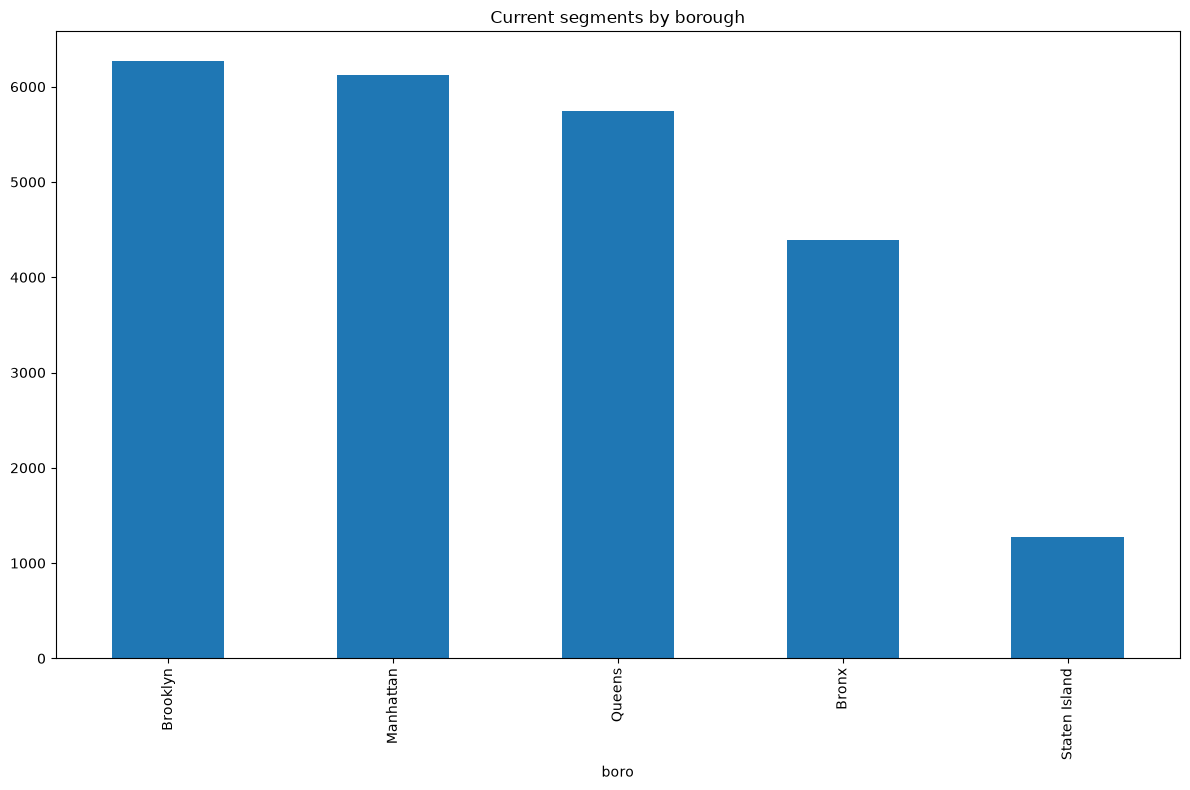

Install date range (excluding 1900 placeholders):
1908-01-08 00:00:00 to 2025-06-23 00:00:00
Rows with 1900-01-01 placeholder date: 196


In [17]:
boro_names = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'}

fig, axes = plt.subplots(1, 1, figsize=(12, 8))

bikes_clean['boro'].map(boro_names).value_counts().plot(kind='bar', title='Current segments by borough')
plt.tight_layout()
plt.show()

instdate = pd.to_datetime(bikes_clean['instdate'], format='%m/%d/%Y', errors='coerce')
print("Install date range (excluding 1900 placeholders):")
print(instdate[instdate.dt.year > 1900].min(), "to", instdate[instdate.dt.year > 1900].max())
print("Rows with 1900-01-01 placeholder date:", (instdate.dt.year == 1900).sum())

In [18]:
print(bikes_clean['the_geom'].iloc[0][:120])
bikes_clean['lanecount'].value_counts().sort_index()

MULTILINESTRING ((-74.192429667502 40.521741493622734, -74.1951900846669 40.519998791664904))


lanecount
0      354
1    11792
2    11580
3       81
Name: count, dtype: int64

## 3. Parks Zones

Park Zones is an NYC Parks Department dataset that subdivides the city's larger parks (generally over 20 acres) into smaller, manageable sections called "zones," used for maintenance planning and inspections. Each zone is linked to its parent park (via GISPROPNUM/PROPNAME) and has its own geometry (multipolygon), allowing precise identification of a specific area within a park rather than the park as a whole. Alongside standard zones, the layer also includes small "sitting areas" that didn't meet the size criteria for a full zone. The dataset includes geographic references (borough, community board, zipcode) and categorizes zones by use type (SUBCATEGORY — e.g., ballfields, wooded areas), plus an active/retired flag to filter out defunct zones. For the Citi Bike project, this dataset is useful as a source of green/recreational-space data near stations — a potential factor driving bike trip volume beyond pure transit substitution (e.g., leisure trips to parks).

In [19]:
parks = pd.read_csv(DATA_DIR / 'Parks_Zones_20260719.csv', low_memory=False)
print(parks.shape)

(928, 20)


### Columns I kept:

ACRES — zone size in acres; proxy for park size/attractiveness for bike trips

BOROUGH — borough; for borough-level aggregation

COMMUNITYBOARD — join key with other datasets sharing this field

DESCRIPTION — zone + parent park name; for identification

GISPROPNUM — unique parent park ID; lets you aggregate all zones of one park (e.
g., total park area near a station)

PROPNAME — parent park name; for readability/grouping

RETIRED — active/inactive flag; exclude retired zones

SITENAME — specific zone name; finer detail within a park

SUBCATEGORY — zone subcategory (ballfield, wooded area, sitting area, etc.); may correlate with type of bike traffic (sport/leisure)

ZIPCODE — additional aggregation/join level
multipolygon — zone geometry; required for spatial analysis (proximity to Citi 
Bike stations)

In [20]:
# Columns relevant to the Citi Bike project
columns_to_keep = [
    'ACRES',
    'BOROUGH',
    'COMMUNITYBOARD',
    'DESCRIPTION',
    'GISPROPNUM',
    'PROPNAME',
    'RETIRED',
    'SITENAME',
    'SUBCATEGORY',
    'ZIPCODE',
    'multipolygon',
]

parks_clean = parks[columns_to_keep].copy()

# Optional: keep only active (non-retired) zones
parks_clean = parks_clean[parks_clean["RETIRED"] == False]

print(parks_clean.shape)
parks_clean.head()

(928, 11)


,ACRES,BOROUGH,COMMUNITYBOARD,DESCRIPTION,GISPROPNUM,PROPNAME,RETIRED,SITENAME,SUBCATEGORY,ZIPCODE,multipolygon
0,8.696544,M,164,Central Park-Reservoir (Southeast),M010,Central Park,False,NaN,NaN,"10,024",MULTIPOLYGON (((-73.96161017862376 40.78194552...
1,29.353960,M,164,Central Park West,M010,Central Park,False,NaN,NaN,"10,024",MULTIPOLYGON (((-73.96636929169082 40.78695904...
2,0.037745,M,106,Sutton Place Pk-Sutton Place Park,M108P,Sutton Parks,False,NaN,NaN,"10,022",MULTIPOLYGON (((-73.95936846698865 40.75760208...
3,0.145764,M,106,Sutton Place Pk-Sutton Place Park,M108P,Sutton Parks,False,NaN,NaN,"10,022",MULTIPOLYGON (((-73.9607697543487 40.756428323...
4,0.304408,M,106,Sutton Place Pk-Sutton Place Park,M108P,Sutton Parks,False,NaN,NaN,"10,022",MULTIPOLYGON (((-73.96028288516543 40.75719285...


In [21]:
parks_clean.isna().mean().sort_values(ascending=False).mul(100).round(1)

SITENAME          100.0
SUBCATEGORY       100.0
ACRES               0.9
GISPROPNUM          0.9
COMMUNITYBOARD      0.2
BOROUGH             0.0
DESCRIPTION         0.0
PROPNAME            0.0
RETIRED             0.0
ZIPCODE             0.0
multipolygon        0.0
dtype: float64

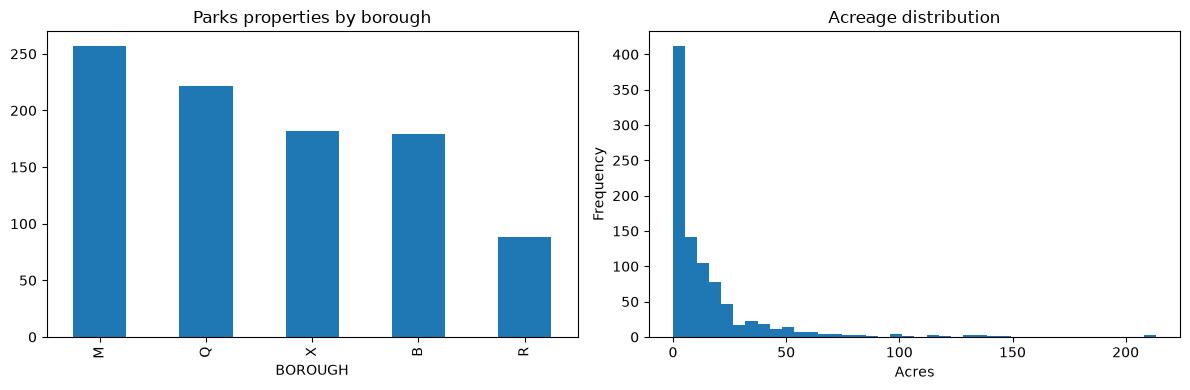

count    920.000000
mean      15.262990
std       25.033567
min        0.033563
25%        0.915533
50%        7.637083
75%       18.563426
max      213.340277
Name: ACRES, dtype: float64

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

parks_clean['BOROUGH'].value_counts().plot(kind='bar', ax=axes[0], title='Parks properties by borough')
parks_clean['ACRES'].plot(kind='hist', bins=40, ax=axes[1], title='Acreage distribution')
axes[1].set_xlabel('Acres')

plt.tight_layout()
plt.show()

parks_clean['ACRES'].describe()

## 4. NYC Zoning Tax Lot Database

Gives zoning type (residential/commercial/industrial/mixed) at the parcel level — a strong feature for predicting trip patterns (residential → commute-out mornings, commercial → commute-in mornings, etc.).

No geometry/coordinates here — only BBL

In [23]:
# Large file (45MB) — read key columns as str to keep codes intact (e.g. leading zeros) and memory down
usecols = ['Borough Code', 'Tax Block', 'Tax Lot', 'BBL', 'Zoning District 1', 'Special District 1']
zoning = pd.read_csv(DATA_DIR / 'NYC_Zoning_Tax_Lot_Database_20260719.csv', dtype=str, usecols=usecols)
print(zoning.shape)
print("Duplicated BBL:", zoning['BBL'].duplicated().sum())

boro_names_str = {str(k): v for k, v in boro_names.items()}
zoning['Borough Code'].map(boro_names_str).value_counts()

(857951, 6)
Duplicated BBL: 1


Borough Code
Queens           324405
Brooklyn         276428
Staten Island    125628
Bronx             89349
Manhattan         42141
Name: count, dtype: int64

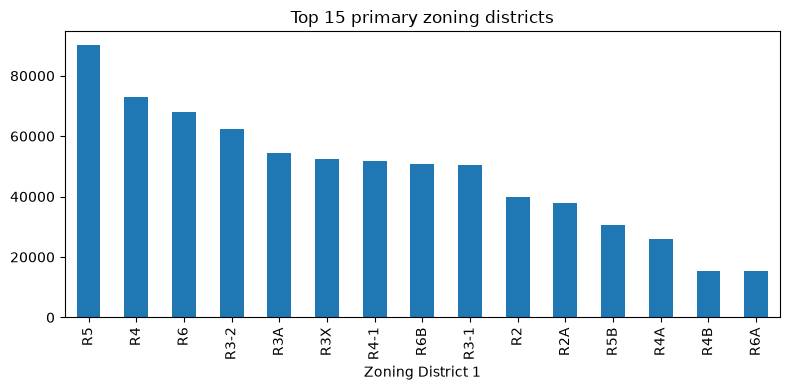

In [24]:
zoning['Zoning District 1'].value_counts().head(15).plot(kind='bar', figsize=(8, 4), title='Top 15 primary zoning districts')
plt.tight_layout()
plt.show()

In [25]:
sch.to_csv(DATA_DIR / "schools.csv", index=False)
bikes_clean.to_csv(DATA_DIR / "bike_lanes.csv", index=False)
parks_clean.to_csv(DATA_DIR / "park_zones.csv", index=False)
zoning.to_csv(DATA_DIR / "zoning.csv", index=False)